# **Step 1. 데이터 다운로드**

In [1]:
!pip install konlpy
!pip install mecab-python3 -y konlpy mecab-python3 python-mecab-ko -q
!pip install python-mecab-ko -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 14.6 MB/s eta 0:00:00

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 18.7 MB/s eta 0:00:00


In [3]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

In [4]:
import os
import re
import time
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import tensorflow as tf

from mecab import MeCab

mecab = MeCab()

def tokenize_kor(sentence):
    return mecab.morphs(sentence)

In [5]:
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

DATA_URL = (
    "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/"
    "master/korean-english-news-v1/korean-english-park.train.tar.gz"
)
TAR_PATH = DATA_DIR / "korean-english-park.train.tar.gz"

if not TAR_PATH.exists():
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(DATA_URL, TAR_PATH)
    print("다운로드 완료:", TAR_PATH)

with tarfile.open(TAR_PATH, "r:gz") as tar:
    tar.extractall(path=DATA_DIR)
    print("압축 해제 완료. 파일 목록:", tar.getnames())

KO_PATH = DATA_DIR / "korean-english-park.train.ko"
EN_PATH = DATA_DIR / "korean-english-park.train.en"

with open(KO_PATH, "r", encoding="utf-8") as f:
    raw_kor = f.read().splitlines()

with open(EN_PATH, "r", encoding="utf-8") as f:
    raw_eng = f.read().splitlines()

print("한국어 문장 수:", len(raw_kor))
print("영어 문장 수:", len(raw_eng))
print("샘플 (KO):", raw_kor[0])
print("샘플 (EN):", raw_eng[0])

assert len(raw_kor) == len(raw_eng), "한/영 문장 쌍의 개수가 일치하지 않습니다."

데이터 다운로드 중...
다운로드 완료: data/korean-english-park.train.tar.gz
압축 해제 완료. 파일 목록: ['korean-english-park.train.en', 'korean-english-park.train.ko']


/tmp/ipykernel_793/3216066726.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


한국어 문장 수: 94123
영어 문장 수: 94123
샘플 (KO): 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
샘플 (EN): Much of personal computing is about "can you top this?"


# **Step 2. 데이터 정제**

In [6]:
# 중복 제거 (병렬 쌍이 흐트러지지 않도록 zip 후 set 처리
cleaned_corpus = list(set(zip(raw_kor, raw_eng)))
print("중복 제거 전:", len(raw_kor), " -> 중복 제거 후:", len(cleaned_corpus))


#  영어 전처리 함수 (기존 방식)
def preprocess_sentence_eng(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,¿])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,¿]+", " ", sentence)
    sentence = sentence.strip()
    return sentence


#  한국어 전처리 함수 (새로 정의: 한글 정규식 적용)
def preprocess_sentence_kor(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,¿])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,¿]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = sentence.strip()
    return sentence


중복 제거 전: 94123  -> 중복 제거 후: 78968


In [7]:
# Mecab 형태소 분석기 준비
mecab = MeCab()


def tokenize_kor(sentence):
    return mecab.morphs(sentence)


def tokenize_eng(sentence):
    sentence = "<start> " + sentence + " <end>"
    return sentence.split()


# 길이 40 이하 데이터만 선별하여 eng_corpus / kor_corpus 구축
MAX_LEN = 40

eng_corpus = []
kor_corpus = []

for kor_raw, eng_raw in cleaned_corpus:
    kor_sent = preprocess_sentence_kor(kor_raw)
    eng_sent = preprocess_sentence_eng(eng_raw)

    if len(kor_sent) == 0 or len(eng_sent) == 0:
        continue

    kor_tokens = tokenize_kor(kor_sent)
    eng_tokens = tokenize_eng(eng_sent)

    if len(kor_tokens) <= MAX_LEN and len(eng_tokens) <= MAX_LEN:
        kor_corpus.append(" ".join(kor_tokens))
        eng_corpus.append(" ".join(eng_tokens))

print("정제 및 길이 필터링 후 데이터 수:", len(kor_corpus))
print("샘플 KOR:", kor_corpus[0])
print("샘플 ENG:", eng_corpus[0])

정제 및 길이 필터링 후 데이터 수: 61536
샘플 KOR: 그 는 절도 와 마리화나 소지 등 의 잘못 에 대해 책임 을 지 고 싶 어 자백 을 결심 했 다 고 말 했 다 .
샘플 ENG: <start> she said she decided to plead guilty to felony theft and misdemeanor marijuana possession because she wanted to take responsibility for her actions . <end>


# **Step 3. 데이터 토큰화**

In [8]:
VOCAB_SIZE = 12000  # 최소 10,000 이상 (실험을 통해 결정)


def tokenize(corpus, vocab_size=VOCAB_SIZE):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        num_words=vocab_size, filters="", oov_token="<unk>"
    )
    tokenizer.fit_on_texts(corpus)

    tensor = tokenizer.texts_to_sequences(corpus)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding="post")

    return tensor, tokenizer


kor_tensor, kor_tokenizer = tokenize(kor_corpus, VOCAB_SIZE)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, VOCAB_SIZE)

print("Korean tensor shape:", kor_tensor.shape)
print("English tensor shape:", eng_tensor.shape)

KOR_VOCAB_SIZE = min(VOCAB_SIZE, len(kor_tokenizer.word_index) + 1)
ENG_VOCAB_SIZE = min(VOCAB_SIZE, len(eng_tokenizer.word_index) + 1)
print("Korean vocab size:", KOR_VOCAB_SIZE)
print("English vocab size:", ENG_VOCAB_SIZE)

BUFFER_SIZE = len(kor_tensor)
BATCH_SIZE = 64
steps_per_epoch = BUFFER_SIZE // BATCH_SIZE

dataset = tf.data.Dataset.from_tensor_slices((kor_tensor, eng_tensor))
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

Korean tensor shape: (61536, 40)
English tensor shape: (61536, 40)
Korean vocab size: 12000
English vocab size: 12000


# **Step 4. 모델설계**

In [9]:
EMBEDDING_DIM = 256
HIDDEN_UNITS = 512  # 실험을 통해 조정 가능


class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super(Encoder, self).__init__()
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(
            enc_units,
            return_sequences=True,
            return_state=True,
            recurrent_initializer="glorot_uniform",
        )

    def call(self, x, hidden):
        x = self.embedding(x)
        output, state = self.gru(x, initial_state=hidden)
        return output, state

    def initialize_hidden_state(self, batch_size):
        return tf.zeros((batch_size, self.enc_units))


class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights


class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units):
        super(Decoder, self).__init__()
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(
            dec_units,
            return_sequences=True,
            return_state=True,
            recurrent_initializer="glorot_uniform",
        )
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x)
        output = tf.reshape(output, (-1, output.shape[2]))
        x = self.fc(output)
        return x, state, attention_weights


encoder = Encoder(KOR_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_UNITS)
decoder = Decoder(ENG_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_UNITS)

optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction="none"
)


def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)


# **Step 5. 모델학습/비교**

In [11]:

# Embedding / Hidden Size 비교 실험
# 1차(baseline): embedding=256, hidden=512
# 2차(light):    embedding=256, hidden=256
# 2차(heavy):    embedding=256, hidden=1024


CONFIGS = [
    {"name": "baseline_emb256_hid512", "embedding_dim": 256, "hidden_units": 512},
    {"name": "light_emb256_hid256",    "embedding_dim": 256, "hidden_units": 256},
    {"name": "heavy_emb256_hid1024",   "embedding_dim": 256, "hidden_units": 1024},
]

SHORT_EPOCHS = 3  # 비교 목적이므로 짧게 (원하면 조정)


def compute_loss(real, pred, loss_object):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)


def train_one_config(embedding_dim, hidden_units, epochs=SHORT_EPOCHS):
    """주어진 embedding/hidden 크기로 encoder/decoder를 새로 만들어 학습"""
    encoder = Encoder(KOR_VOCAB_SIZE, embedding_dim, hidden_units)
    decoder = Decoder(ENG_VOCAB_SIZE, embedding_dim, hidden_units)
    optimizer = tf.keras.optimizers.Adam()
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction="none"
    )

    @tf.function
    def train_step(kor, eng, enc_hidden):
        loss = 0
        with tf.GradientTape() as tape:
            enc_output, enc_hidden = encoder(kor, enc_hidden)
            dec_hidden = enc_hidden
            dec_input = tf.expand_dims(
                [eng_tokenizer.word_index["<start>"]] * BATCH_SIZE, 1
            )
            for t in range(1, eng.shape[1]):
                predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
                loss += compute_loss(eng[:, t], predictions, loss_object)
                dec_input = tf.expand_dims(eng[:, t], 1)

        batch_loss = loss / int(eng.shape[1])
        variables = encoder.trainable_variables + decoder.trainable_variables
        gradients = tape.gradient(loss, variables)
        optimizer.apply_gradients(zip(gradients, variables))
        return batch_loss

    step_loss_history = []  # 스텝 단위 loss (하강 곡선 비교용)

    for epoch in range(epochs):
        enc_hidden = encoder.initialize_hidden_state(BATCH_SIZE)
        total_loss = 0

        for batch, (kor, eng) in enumerate(dataset.take(steps_per_epoch)):
            batch_loss = train_step(kor, eng, enc_hidden)
            total_loss += batch_loss
            step_loss_history.append(float(batch_loss.numpy()))

        avg_loss = total_loss / steps_per_epoch
        print(f"  Epoch {epoch+1}/{epochs}  Avg Loss: {avg_loss:.4f}")

    return encoder, decoder, hidden_units, step_loss_history


def evaluate_with_model(sentence, encoder, decoder, hidden_units, max_length_targ=MAX_LEN):
    attention_plot = np.zeros((max_length_targ, MAX_LEN))

    sentence_p = preprocess_sentence_kor(sentence)
    tokens = tokenize_kor(sentence_p)

    inputs = [
        kor_tokenizer.word_index.get(tok, kor_tokenizer.word_index.get("<unk>", 1))
        for tok in tokens
    ]
    inputs = tf.keras.preprocessing.sequence.pad_sequences(
        [inputs], maxlen=kor_tensor.shape[1], padding="post"
    )
    inputs = tf.convert_to_tensor(inputs)

    result = ""
    hidden = tf.zeros((1, hidden_units))
    enc_out, enc_hidden = encoder(inputs, hidden)
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([eng_tokenizer.word_index["<start>"]], 0)

    for t in range(max_length_targ):
        predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_out)
        predicted_id = tf.argmax(predictions[0]).numpy()
        word = eng_tokenizer.index_word.get(predicted_id, "<unk>")
        result += word + " "

        if word == "<end>":
            break

        dec_input = tf.expand_dims([predicted_id], 0)

    return result.strip()

EXAMPLES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

# --- 3개 설정 순차 학습 ---
results = {}

for cfg in CONFIGS:
    print(f"\n=== {cfg['name']} 학습 시작 "
          f"(embedding={cfg['embedding_dim']}, hidden={cfg['hidden_units']}) ===")

    encoder, decoder, hidden_units, loss_history = train_one_config(
        cfg["embedding_dim"], cfg["hidden_units"], epochs=SHORT_EPOCHS
    )

    translations = {
        ex: evaluate_with_model(ex, encoder, decoder, hidden_units) for ex in EXAMPLES
    }

    results[cfg["name"]] = {
        "config": cfg,
        "loss_history": loss_history,
        "translations": translations,
    }
    print("학습 종료")


=== baseline_emb256_hid512 학습 시작 (embedding=256, hidden=512) ===
  Epoch 1/3  Avg Loss: 3.2364
  Epoch 2/3  Avg Loss: 2.8509
  Epoch 3/3  Avg Loss: 2.6006
학습 종료

=== light_emb256_hid256 학습 시작 (embedding=256, hidden=256) ===
  Epoch 1/3  Avg Loss: 3.2790
  Epoch 2/3  Avg Loss: 2.9536
  Epoch 3/3  Avg Loss: 2.7643
학습 종료

=== heavy_emb256_hid1024 학습 시작 (embedding=256, hidden=1024) ===
  Epoch 1/3  Avg Loss: 3.1921
  Epoch 2/3  Avg Loss: 2.7050
  Epoch 3/3  Avg Loss: 2.4318
학습 종료


- Embedding Size : 모델의 표현력을 결정하며, 너무 작으면 단어의 미묘한 차이를 담기 어렵고, 크면 단어간 정교한 의미 파악은 가능하지만 학습할 데이터가 많아짐
- Hidden size : 모델이 문맥정보를 기억하고 처리하는 내부 상태(Hidden State)의 차원 수. 값이 낮아지면 복잡한 문장의 이해력이 부족하고 값이 커질수록 긴 문장이나 복잡한 구조를 잘 이해하지만 지나치게 크면 모델이 데이터의 패턴을 외워버리는 과적합 우려

# **Step 6. 결과 비교**

**결과비교1: loss값**

In [14]:
import numpy as np

# 최근 N step 평균으로 "최종 loss" 수치 비교
N = 100
print(f"{'설정':30s} {'최종 평균 loss':>15s} {'전체 최소 loss':>15s}")
for name, res in results.items():
    hist = res["loss_history"]
    final_avg = np.mean(hist[-N:])
    min_loss = np.min(hist)
    print(f"{name:30s} {final_avg:15.4f} {min_loss:15.4f}")

설정                                  최종 평균 loss      전체 최소 loss
baseline_emb256_hid512                  2.5101          2.1827
light_emb256_hid256                     2.6944          2.3551
heavy_emb256_hid1024                    2.3943          2.0528


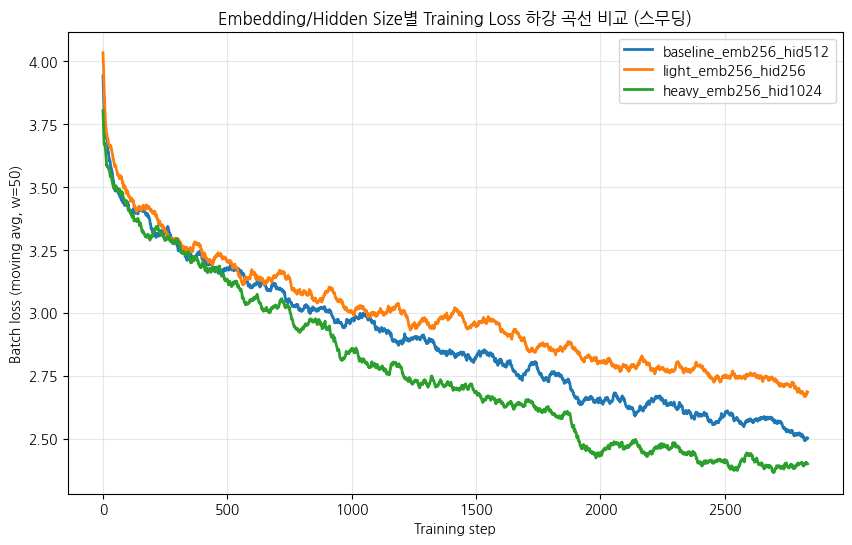

In [15]:
# 이동평균으로 스무딩한 그래프 (겹침 문제 완화)
def moving_average(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(10, 6))
for name, res in results.items():
    smoothed = moving_average(res["loss_history"], w=50)
    plt.plot(smoothed, label=name, linewidth=2)
plt.xlabel("Training step")
plt.ylabel("Batch loss (moving avg, w=50)")
plt.title("Embedding/Hidden Size별 Training Loss 하강 곡선 비교 (스무딩)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- hidden size를 키우면 training loss가 낮아진다"는 이번 실험에서 명확히 확인됨

**결과비교2: 번역 품질**

In [13]:

# 결과 비교 2: 예문 4개 번역 품질 비교 표

print("\n" + "=" * 100)
print("예문별 번역 결과 비교")
print("=" * 100)
for ex in EXAMPLES:
    print(f"\nK) {ex}")
    for name, res in results.items():
        cfg = res["config"]
        print(f"  [{name:25s}] (emb={cfg['embedding_dim']}, hid={cfg['hidden_units']:4d}) "
              f"-> {res['translations'][ex]}")


예문별 번역 결과 비교

K) 오바마는 대통령이다.
  [baseline_emb256_hid512   ] (emb=256, hid= 512) -> obama s campaign is a new york senator . <end>
  [light_emb256_hid256      ] (emb=256, hid= 256) -> obama s . <end>
  [heavy_emb256_hid1024     ] (emb=256, hid=1024) -> obama is a <unk> . <end>

K) 시민들은 도시 속에 산다.
  [baseline_emb256_hid512   ] (emb=256, hid= 512) -> the <unk> is the <unk> . <end>
  [light_emb256_hid256      ] (emb=256, hid= 256) -> the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the
  [heavy_emb256_hid1024     ] (emb=256, hid=1024) -> the <unk> is a <unk> . <end>

K) 커피는 필요 없다.
  [baseline_emb256_hid512   ] (emb=256, hid= 512) -> it s not a <unk> . <end>
  [light_emb256_hid256      ] (emb=256, hid= 256) -> the <unk> is a <unk> . <end>
  [heavy_emb256_hid1024     ] (emb=256, hid=1024) -> it s not a lot of <unk> . <end>

K) 일곱 명의 사망자가 발생했다.
  [baseline_emb256_hid512   ] (

- 번역결과를 보면 3개 모두 만족스럽지는 못하지만 그나마 K1 예시의 basedline model(emb=256, hid=512)의 번역 문장 완성도가 높음
- training loss가 가장 낮다고 해서 가장 자연스러운 번역을 내놓는 건 아니라는 걸 실제 데이터로 확인
- 모든 모델의 번역에서 UNK가 나오고 있는데 원인은 1) vocab(size =12000)에 없는 단어이거나 2) 3 epoch으로 충분히 학습되지 않았을 가능성으로 유추
- 예시 2번째와 4번째의 모델(emb=256, hid=256)에서 문장을 끝내는 <end> 토큰이 나오지 못하고 max-len(40)까지 가서 강제 종료됨--> 데이터를 충분히 표현하지 못해서 디코더가 문장을 어떻게 끝내야 할지조차 제대로 못 배운 상태   

In [17]:
def evaluate_with_attention(sentence, encoder, decoder, hidden_units, max_length_targ=MAX_LEN):
    attention_plot = np.zeros((max_length_targ, MAX_LEN))

    sentence_p = preprocess_sentence_kor(sentence)
    tokens = tokenize_kor(sentence_p)

    inputs = [
        kor_tokenizer.word_index.get(tok, kor_tokenizer.word_index.get("<unk>", 1))
        for tok in tokens
    ]
    inputs = tf.keras.preprocessing.sequence.pad_sequences(
        [inputs], maxlen=kor_tensor.shape[1], padding="post"
    )
    inputs = tf.convert_to_tensor(inputs)

    result = ""
    hidden = tf.zeros((1, hidden_units))
    enc_out, enc_hidden = encoder(inputs, hidden)
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([eng_tokenizer.word_index["<start>"]], 0)

    for t in range(max_length_targ):
        predictions, dec_hidden, attention_weights = decoder(dec_input, dec_hidden, enc_out)

        attention_weights = tf.reshape(attention_weights, (-1,))
        attention_plot[t] = attention_weights.numpy()[:MAX_LEN]

        predicted_id = tf.argmax(predictions[0]).numpy()
        word = eng_tokenizer.index_word.get(predicted_id, "<unk>")
        result += word + " "

        if word == "<end>":
            break

        dec_input = tf.expand_dims([predicted_id], 0)

    return result.strip(), sentence_p, attention_plot


def plot_attention_map(sentence, encoder, decoder, hidden_units, title=""):
    result, processed_sentence, attention_plot = evaluate_with_attention(
        sentence, encoder, decoder, hidden_units
    )
    print(f"Input:     {sentence}")
    print(f"Predicted: {result}")

    predicted_tokens = result.split()
    sentence_tokens = processed_sentence.split()
    attention_plot = attention_plot[: len(predicted_tokens), : len(sentence_tokens)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.matshow(attention_plot, cmap="viridis")

    ax.set_xticks(range(len(sentence_tokens)))
    ax.set_xticklabels(sentence_tokens, rotation=90, fontsize=12)
    ax.set_yticks(range(len(predicted_tokens)))
    ax.set_yticklabels(predicted_tokens, fontsize=12)

    ax.set_xlabel("입력 (한국어)")
    ax.set_ylabel("출력 (영어)")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig("attention_map_obama.png", bbox_inches="tight")
    plt.show()

  Epoch 1/3  Avg Loss: 3.2410
  Epoch 2/3  Avg Loss: 2.8903
  Epoch 3/3  Avg Loss: 2.6683
Input: 오바마는 대통령이다.
Predicted: obama is the president . <end>


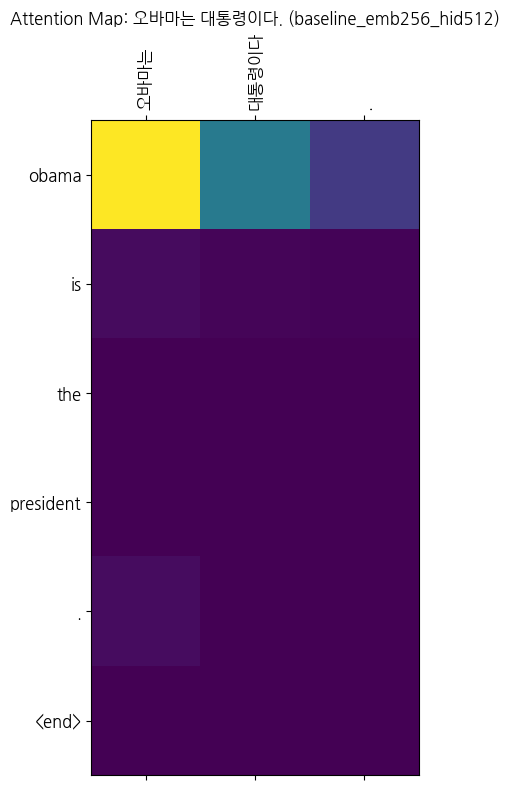

In [21]:
baseline_encoder, baseline_decoder, baseline_hidden, _ = train_one_config(256, 512, epochs=SHORT_EPOCHS)
plot_attention_map("오바마는 대통령이다.", baseline_encoder, baseline_decoder, hidden_units=512,
                    title="Attention Map: 오바마는 대통령이다. (baseline_emb256_hid512)")

[회고] "loss 순위 ~ = 실제 결과물 품질의 순위"

- hidden size를 바꿔가며 비교했을 때, hidden size가 클수록(heavy, 1024) training loss는 확실히 더 낮았지만, 실제 K1~K4 번역 결과를 보면 <unk>가 오히려 더 많이 나오고 baseline(512)과 비교해 의미상 더 나은 번역이라고 보기 어려웠음.
- 반대로 hidden=256(light)은 loss도 가장 높았고 실제로 문장을 끝맺지 못하는 반복 루프 실패까지 확인했고 이 경험으로 loss 순위 = 실제 결과물 품질의 순위"가 아니라는 것
- 그리고 train/validation을 분리하지 않은 이번 실험 구조상 loss가 낮다는 게 곧 일반화 성능을 의미하지 않는다는 점을 알게 되었고 향후 모델을 비교할 때는 정량 지표(loss)와 정성 평가(실제 출력 샘플)를 항상 같이 확인해야 한다는 배움을 얻음